In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Srivaishnavi\Downloads\movie_success_prediction_1000.csv")

print(df.head())
print(df.shape)

   movie_id    title     genre language     budget  popularity  vote_average  \
0         1  Movie_1   Romance   Telugu  107000000       77.49           7.9   
1         2  Movie_2    Comedy   Korean  184000000       92.18           6.2   
2         3  Movie_3     Drama   Korean   97000000       62.66           9.4   
3         4  Movie_4  Thriller  English   19000000       75.35           8.5   
4         5  Movie_5  Thriller  English  111000000       78.14           6.9   

   vote_count  runtime    revenue  success  
0       11690       91  291488291        1  
1       10986      139  383774304        1  
2       12966      106  137073737        1  
3        1188      135   62320673        1  
4        3463      185  283518316        1  
(1000, 11)


In [10]:
from sklearn.preprocessing import LabelEncoder

le_genre = LabelEncoder()
le_language = LabelEncoder()
le_title = LabelEncoder()

df["genre"] = le_genre.fit_transform(df["genre"])
df["language"] = le_language.fit_transform(df["language"])
df["title"] = le_title.fit_transform(df["title"])

In [11]:
X = df.drop("success", axis=1)
y = df["success"]

print(X.shape)
print(y.shape)

(1000, 10)
(1000,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", round(accuracy * 100, 2), "%")

Accuracy = 98.5 %


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.77      0.87        13
           1       0.98      1.00      0.99       187

    accuracy                           0.98       200
   macro avg       0.99      0.88      0.93       200
weighted avg       0.99      0.98      0.98       200



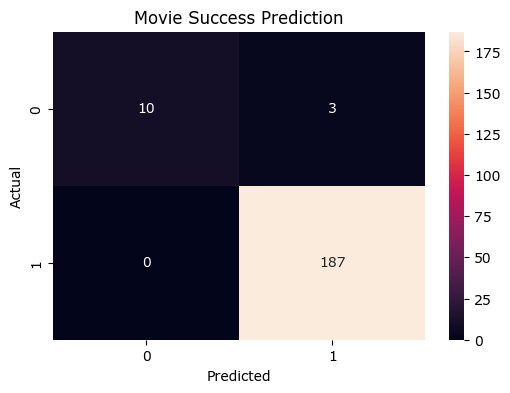

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Movie Success Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

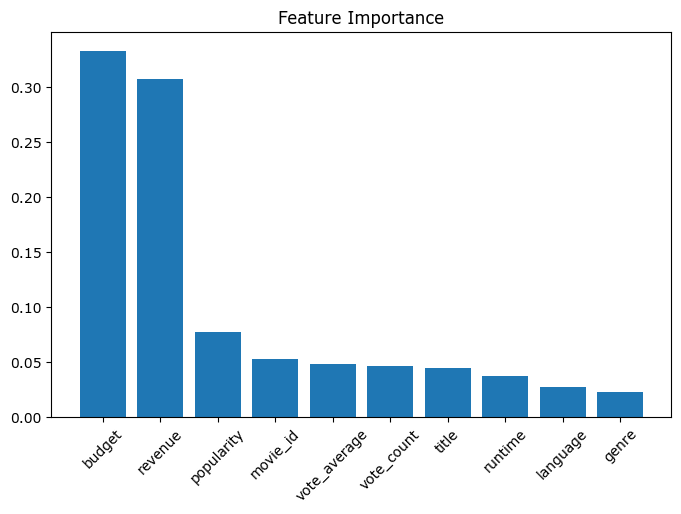

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [20]:
new_movie = pd.DataFrame({
    "movie_id":[1001],
    "title":[0],
    "genre":[1],
    "language":[0],
    "budget":[150000000],
    "popularity":[85.0],
    "vote_average":[8.2],
    "vote_count":[15000],
    "runtime":[150],
    "revenue":[350000000]
})

prediction = model.predict(new_movie)

print("Predicted Success:", prediction[0])

Predicted Success: 1
